In [28]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [87]:
df = pd.read_csv("../data/drug_discovery_virtual_screening_cleaned.csv")
df = df.drop("Unnamed: 0", axis=1)

In [88]:
df

,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,active
0,499.671415,2.487233,1.0,7.0,4.0,113.350817,4.050696,678.0,6.019657,0.812534,12.512165,0.736978,14.972288,0.0
1,436.173570,3.283222,3.0,4.0,4.0,71.981132,3.704408,876.0,6.447408,0.651417,11.538420,0.497915,21.168271,0.0
2,514.768854,3.479480,2.0,11.0,11.0,83.936307,1.869610,658.0,3.925837,0.633467,13.155702,0.782323,9.074061,0.0
3,602.302986,3.038058,0.0,5.0,5.0,79.868125,2.451909,312.0,7.597056,0.513038,12.071822,1.930458,23.080293,0.0
4,426.584663,0.659578,2.0,4.0,5.0,88.198676,1.771936,1418.0,4.249454,0.613571,15.850448,0.300835,2.802846,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,557.015024,3.542686,4.0,5.0,11.0,102.329688,1.470121,240.0,7.862185,0.770925,21.308909,2.320896,27.853256,1.0
1995,447.347874,0.383282,1.0,8.0,5.0,52.321214,3.739447,718.0,7.401501,0.644721,16.578658,0.623047,2.836864,1.0
1996,361.812535,3.019553,0.0,4.0,9.0,86.722469,3.122027,1228.0,5.551238,0.717044,16.829751,0.294636,16.762259,0.0
1997,433.693304,5.965067,0.0,4.0,10.0,86.932238,3.866579,1244.0,5.680128,0.661245,10.604194,0.348628,33.882348,1.0


In [90]:
(df_train, df_test) = train_test_split(df, train_size=0.8, test_size=0.2, random_state=8123)

In [91]:
X_train = df_train.drop("active", axis=1)
y_train = df_train['active']

X_test = df_test.drop("active", axis=1)
y_test = df_test['active']

In [76]:
# Do not standardize: 
# stnd = StandardScaler().set_output(transform='pandas')
# X_train = stnd.fit_transform(X_train)
# X_test = stnd.transform(X_test)

In [92]:
grid = {'max_depth': np.arange(1, 15)}

In [93]:
X_train

,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio
123,309.814894,3.105664,0.0,5.0,7.0,86.674006,2.317694,1386.0,4.945247,0.518685,10.628049,0.223532
751,314.831539,5.859530,0.0,6.0,5.0,68.204934,3.189295,1306.0,6.999010,0.681064,15.906075,0.241065
1728,633.818368,0.025784,3.0,2.0,1.0,47.754572,3.416635,1326.0,5.712992,0.605189,12.663326,0.477993
390,360.158533,0.730718,2.0,5.0,7.0,93.827556,0.939950,1464.0,6.741303,0.645325,15.359808,0.246010
100,308.462926,4.064614,3.0,5.0,9.0,127.219495,5.199596,824.0,6.632438,0.664293,15.816695,0.374348
...,...,...,...,...,...,...,...,...,...,...,...,...
1412,495.588777,6.487330,1.0,3.0,6.0,109.877508,4.482814,220.0,7.499792,0.623508,15.417522,2.252676
213,515.139125,2.821865,1.0,3.0,5.0,100.796159,2.736917,298.0,7.486244,0.671118,14.520029,1.728655
1110,430.931760,1.757324,2.0,6.0,9.0,67.558528,2.074811,510.0,9.500314,0.838721,13.332382,0.844964
425,586.863156,4.271382,1.0,7.0,10.0,126.153425,0.891075,953.0,5.968819,0.752446,15.635624,0.615806


In [94]:
tree = DecisionTreeClassifier()
treeCV = GridSearchCV(tree, param_grid=grid, n_jobs=-1, verbose=3)
treeCV.fit(X_train, y_train)

Fitting 5 folds for each of 14 candidates, totalling 70 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 1, 2..., 12, 13, 14])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and can

In [95]:
depth = treeCV.best_params_['max_depth']
tree = DecisionTreeClassifier(max_depth=depth)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
y_prob = tree.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Decision Tree Accuracy:", accuracy)
print("Decision Tree ROC-AUC:", roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Decision Tree Accuracy: 0.895
Decision Tree ROC-AUC: 0.9173527272727272

Confusion Matrix:
[[257  18]
 [ 24 101]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.93      0.92       275
         1.0       0.85      0.81      0.83       125

    accuracy                           0.90       400
   macro avg       0.88      0.87      0.88       400
weighted avg       0.89      0.90      0.89       400



[Text(0.5, 0.9, 'logp <= 3.948\ngini = 0.422\nsamples = 1599\nvalue = [1116.0, 483.0]'),
 Text(0.25, 0.7, 'protein_pi <= 8.049\ngini = 0.161\nsamples = 994\nvalue = [906, 88]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'logp <= 3.816\ngini = 0.114\nsamples = 905\nvalue = [850, 55]'),
 Text(0.0625, 0.3, 'molecular_weight <= 100.107\ngini = 0.093\nsamples = 858\nvalue = [816, 42]'),
 Text(0.03125, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.09375, 0.1, 'gini = 0.089\nsamples = 856\nvalue = [816, 40]'),
 Text(0.1875, 0.3, 'protein_pi <= 6.366\ngini = 0.4\nsamples = 47\nvalue = [34, 13]'),
 Text(0.15625, 0.1, 'gini = 0.0\nsamples = 23\nvalue = [23, 0]'),
 Text(0.21875, 0.1, 'gini = 0.497\nsamples = 24\nvalue = [11, 13]'),
 Text(0.375, 0.5, 'logp <= 3.27\ngini = 0.467\nsamples = 89\nvalue = [56, 33]'),
 Text(0.3125, 0.3, 'logp <= 2.892\ngini = 0.185\nsamples = 58\nvalue = [52, 6]'),
 Text(0.28125, 0.1, 'gini = 0.043\nsamples = 46\nvalue = [45, 1]'),
 Text(0.34375, 0.1, 'g

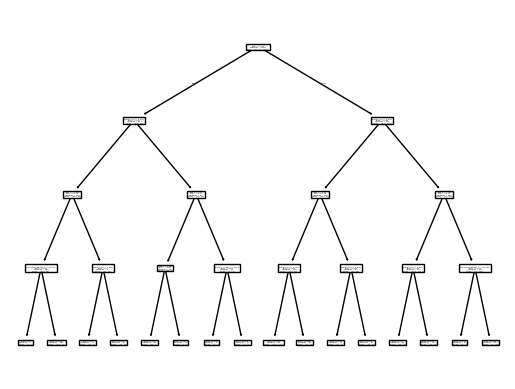

In [96]:
plot_tree(tree, feature_names=df.columns)

In [64]:
grid = {'learning_rate': [0.005, 0.01, 0.015], 'n_estimators': np.arange(35, 65, 1), 'max_depth': np.arange(1, 10)}

In [ ]:
gbt = GradientBoostingClassifier()
gbtCV = GridSearchCV(gbt, param_grid=grid, n_jobs=-1, verbose=2, return_train_score=True)
gbtCV.fit(X_train, y_train)

Fitting 5 folds for each of 810 candidates, totalling 4050 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.005, 0.01, ...], 'max_depth': array([1, 2, ..., 6, 7, 8, 9]), 'n_estimators': array([35, 36..., 62, 63, 64])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

In [66]:
print("Gradient Boosing Trees:")
print("Optimal hyperparameters:", gbtCV.best_params_)
print("Optimal Valid R2 =", gbtCV.best_score_)

Gradient Boosing Trees:
Optimal hyperparameters: {'learning_rate': 0.01, 'max_depth': np.int64(1), 'n_estimators': np.int64(44)}
Optimal Valid R2 = 0.8999353448275862


In [ ]:
y_pred = gbtCV.predict(X_test)
y_prob = gbtCV.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Gradient Boosting Accuracy:", accuracy)
print("Gradient Boosting ROC-AUC:", roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Gradient Boosting Accuracy: 0.915
Gradient Boosting ROC-AUC: 0.9257018181818182

Confusion Matrix:
[[264  11]
 [ 23 102]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94       275
         1.0       0.90      0.82      0.86       125

    accuracy                           0.92       400
   macro avg       0.91      0.89      0.90       400
weighted avg       0.91      0.92      0.91       400

